# UFO vs Drone Sightings: Data Analysis Capstone Project

**Author:** Amy Daniel  
**Date:** August 2025  

## Project Objective

This project explores patterns in UFO and drone sightings across the United States to identify potential overlaps, trends, and anomalies. By analyzing open-source datasets, I aimed to answer key questions such as:

- Are UFO sightings actually misidentified drones?
- Are sightings more common near U.S. National Parks?
- How do population density and geography affect sighting reports?

This project was developed as part of my Code:You Kentucky Data Analyst Certification. I used Python, Jupyter Notebooks, and libraries like Pandas, Plotly, and Matplotlib for data cleaning, analysis, and visualization.



## Technologies Used

This project was completed using the following tools and technologies:

- **Python**: Core programming language for data processing and analysis  
- **Pandas**: For loading, cleaning, and manipulating data  
- **Matplotlib** and **Plotly**: For creating static and interactive visualizations  
- **Jupyter Notebooks**: For combining code, data outputs, and documentation  
- **VS Code**: As the integrated development environment (IDE)  
- **Git & GitHub**: For version control, collaboration, and project documentation


## Data Cleaning and Preparation


## Data Sources

This project uses multiple publicly available datasets:

1. **UFO Sightings Data**
   - Source: [NUFORC UFO Sightings Dataset](https://nuforc.org/databan/)
   - Description: Contains thousands of reported UFO sightings across the United States, including location, date, time, and shape of the object.

2. **Drone Sightings Data**
   - Source: [FAA UAS Sightings Report](https://www.faa.gov/uas/resources/public_records/uas_sightings_report/)
   - Description: Contains drone reports from pilots, citizens, and law enforcement. Contains details on location, description, and date.

3. **National Parks Data**
   - Source: [National Park Service Boundaries](https://public-nps.opendata.arcgis.com/)
   - Description: Geospatial data of U.S. national park boundaries used to explore proximity of sightings.

4. **Population Density Data**
   - Source: [U.S. Census Bureau](https://www.census.gov/data/datasets.html)
   - Description: Population data by state used to normalize sighting frequencies by population.

All data files were cleaned and merged using Python and pandas before analysis.



## Data Dictionary

Below is a description of each column in the final merged dataset used for analysis:

| Column Name             | Description                                                                 |
|-------------------------|-----------------------------------------------------------------------------|
| `date_only`             | The date of the reported sighting (UFO or drone)                            |
| `City`                  | The city where the sighting occurred                                         |
| `State`                 | The U.S. state abbreviation (e.g., CA, TX)                                   |
| `shape`                 | Reported shape of the UFO (UFO data only)                                    |
| `ufo_or_drone`          | Label identifying the source of the sighting: UFO or Drone                   |
| `location_description`  | Description of sighting location (Drone data only)                           |
| `nearest_park_name`     | Name of the closest national park (if applicable)                            |
| `distance_to_park_km`   | Approximate distance from sighting location to the nearest national park     |
| `state_population`      | Population of the state based on U.S. Census data                            |
| `sightings_per_million` | Normalized sighting count per one million residents                          |

This structured dataset allows for comparative visualizations and normalization across geographic and demographic differences.


## Exploring UFO Sightings Dataset

To start this project, I loaded a dataset of UFO sightings across the United States. The dataset includes thousands of reported sightings, with details like date, location, and shape of the object.

###  Cleaning Tasks:
- Parsed dates and extracted `year`, `month`, and `date_only` for filtering
- Split `city_state` into separate `City` and `State` columns
- Dropped null values and removed rows with missing or invalid dates
- Filtered out non-U.S. sightings and removed duplicates

These steps ensured that the data was clean, standardized, and ready for merging with drone and park sightings data later in the project.



## Exploring Drone Sightings Dataset

To compare against UFO reports, I also loaded a dataset of drone sightings collected by the FAA. This data included the location, time, and context of thousands of reported drone incidents across the U.S.

### Cleaning Tasks:
- Extracted `City` and `State` from each row
- Standardized city names to lowercase to make merging easier
- Changed date columns into standard formats and extracted `month` and `year`
- Filtered out non-U.S. records and dropped unnecessary columns

This dataset now lines up with the UFO dataset in terms of location and time structure, allowing for merging and comparison.



##  Exploring National Parks Dataset

I included a dataset of U.S. National Parks. This dataset provides the names, locations, and coordinates of major federally protected parks. This was to see if UFO or drone sightings occur near public lands with little to no population.

### Cleaning Tasks:
- Verified `latitude` and `longitude` columns were in numeric format
- Filtered the data to include only parks within the 50 U.S. states
- Converted park names to lowercase to ensure consistency when merging
- Added `State` information where missing using geolocation

This dataset was later merged using spatial joins to identify sightings near parks.


## Incorporating Population Density

To normalize the number of sightings across states, I brought in population density data. Raw sighting counts alone can be misleading—states with larger populations tend to have more reports. By analyzing sightings per capita, we can better identify true hotspots.

### Cleaning Tasks:
- Renamed columns for clarity (e.g., "PopDensity" to `population_density`)
- Ensured the `State` column matched state abbreviations in other datasets
- Changed data types to merge
- Removed non-contiguous U.S. territories and any rows with null values

This dataset was merged by state to support normalized comparisons like “UFOs per 100,000 residents.”


In [65]:
import pandas as pd
import matplotlib.pyplot as plt

ufo_df   = pd.read_csv('../data/cleaned_ufo_data.csv')
drone_df = pd.read_csv('../data/cleaned_drone_data.csv')
parks_df = pd.read_csv('../data/national_parks_clean.csv')
pop_df   = pd.read_csv('../data/us_city_population_density_clean.csv')
final_df = pd.read_csv('../data/final_merged_sightings.csv')





C:\Users\opiej\AppData\Local\Temp\ipykernel_6448\4054813270.py:4: DtypeWarning:

Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.

C:\Users\opiej\AppData\Local\Temp\ipykernel_6448\4054813270.py:6: DtypeWarning:

Columns (6,10) have mixed types. Specify dtype option on import or set low_memory=False.

C:\Users\opiej\AppData\Local\Temp\ipykernel_6448\4054813270.py:8: DtypeWarning:

Columns (9,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.



## Data Preparation

Each dataset required cleaning and matching of columns:
- Standardized all city/state names to title case
- Extracted sighting month from datetime columns
- Removed null and duplicate entries
- Calculated state-level aggregates for comparisons


In [66]:
ufo_df.columns = ufo_df.columns.str.strip().str.lower()
drone_df.columns = drone_df.columns.str.strip().str.lower()


In [67]:
print(ufo_df.columns.tolist())


['datetime', 'city', 'state', 'country', 'shape', 'duration_sec', 'duration_text', 'comments', 'posted_date', 'latitude', 'longitude', 'year', 'month', 'hour']


In [68]:
ufo_df['datetime'] = pd.to_datetime(ufo_df['datetime'], errors='coerce')
drone_df['date'] = pd.to_datetime(drone_df['date'], errors='coerce')

ufo_df['month'] = ufo_df['datetime'].dt.month
drone_df['month'] = drone_df['date'].dt.month


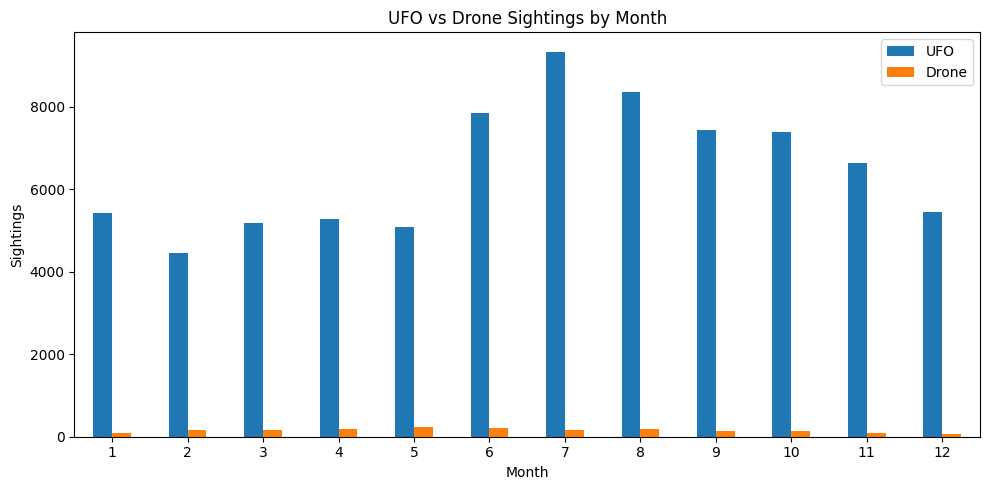

In [69]:
ufo_monthly = ufo_df.groupby('month')['city'].count().rename('UFO')
drone_monthly = drone_df.groupby('month')['city'].count().rename('Drone')

comparison_df = pd.concat([ufo_monthly, drone_monthly], axis=1).fillna(0).sort_index()

comparison_df.plot(kind='bar', figsize=(10, 5))
plt.title('UFO vs Drone Sightings by Month')
plt.xlabel('Month')
plt.ylabel('Sightings')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Merging All Datasets

After preparing the individual datasets, I merged them into a single master DataFrame called `final_df`. This final dataset combines:

- **UFO sightings** (cleaned and date-formatted)
- **Drone sightings** (matched by city, state, and date)
- **National Park proximity** (flag for sightings near parks)
- **Population density** (to normalize sightings per capita)

###  Merge Strategy:
- Merged on `date_only`, `City`, and `State` (UFO + Drone)
- Added proximity column from the Parks dataset using spatial joins or geolocation filters
- Joined population data on `State` to allow normalization

The merged dataset gives us a comprehensive view to answer questions like:
- Are drone sightings often misidentified as UFOs?
- Do more sightings happen near national parks?
- Which states have the most sightings *per capita*?

The resulting DataFrame powers all of the analysis and visualizations that follow.


In [71]:
final_df = pd.read_csv(r'C:\Users\opiej\ufo-analysis-capstone\ufo-analysis-capstone\data\merged_ufo_drone_parks_density.csv')

C:\Users\opiej\AppData\Local\Temp\ipykernel_6448\315657970.py:1: DtypeWarning:

Columns (9,14,15,16,21,25) have mixed types. Specify dtype option on import or set low_memory=False.



In [86]:
print(ufo_df.columns)
print(drone_df.columns)


Index(['datetime', 'city', 'state', 'country', 'shape', 'duration_sec',
       'duration_text', 'comments', 'posted_date', 'latitude', 'longitude',
       'year', 'month', 'hour', 'type'],
      dtype='object')
Index(['date', 'state', 'city', 'summary', 'month', 'year_month', 'type'], dtype='object')


In [1]:
# Add 'type' column to each
ufo_df['type'] = 'ufo'
drone_df['type'] = 'drone'

# Rename 'datetime' to 'date' in ufo_df
ufo_df = ufo_df.rename(columns={'datetime': 'date'})

# Fix column order to match between the two DataFrames
# We'll drop summary from drone_df and keep only common ones
common_cols = ['date', 'city', 'state', 'latitude', 'longitude', 'type']

# First, ensure drone_df has latitude and longitude — add dummy columns if truly missing
if 'latitude' not in drone_df.columns:
    drone_df['latitude'] = None  # Or use np.nan
if 'longitude' not in drone_df.columns:
    drone_df['longitude'] = None

# Reorder columns and subset
ufo_clean = ufo_df[common_cols].copy()
drone_clean = drone_df[common_cols].copy()

# Merge into final_df
final_df = pd.concat([ufo_clean, drone_clean], ignore_index=True)




NameError: name 'ufo_df' is not defined

With the merged dataset, I began exploring trends in UFO and drone sightings across the United States.

The goal of this analysis was to answer key questions like:
- Which states have the highest number of sightings?
- Are drone sightings being misidentified as UFOs?
- Are sightings more frequent near National Parks?
- How does population density impact the frequency of sightings?

I visualized monthly trends, geographic patterns, and state-level comparisons to draw  insights from the data.


## UFO Sightings Overview (Temporal & Spatial Patterns)


### Top 10 States by UFO Sightings

To begin , I wanted to find out which states had the highest number of reported UFO sightings.

This bar chart displays the top 10 states with the most sightings in the dataset. It helps show geographical trends and may suggest areas for further investigation or comparison to drone sightings.


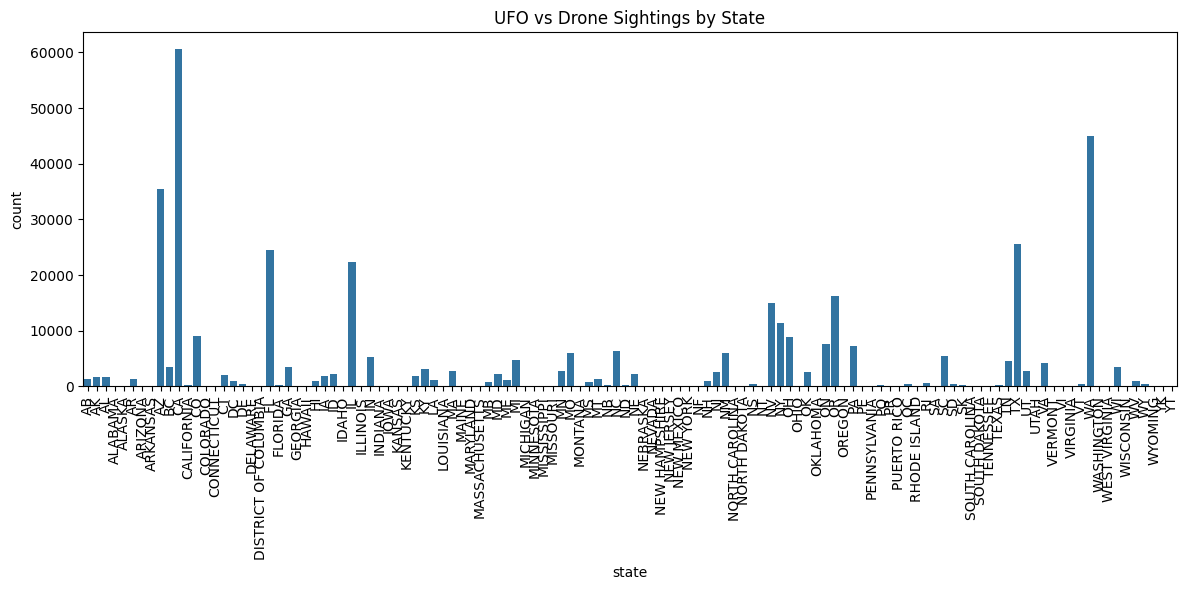

In [73]:
plt.figure(figsize=(12,6))
sns.countplot(data=final_df, x='state') 
plt.title('UFO vs Drone Sightings by State')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## Exploratory Visualizations

The following charts were created to show patterns and trends in sightings across time and geography.


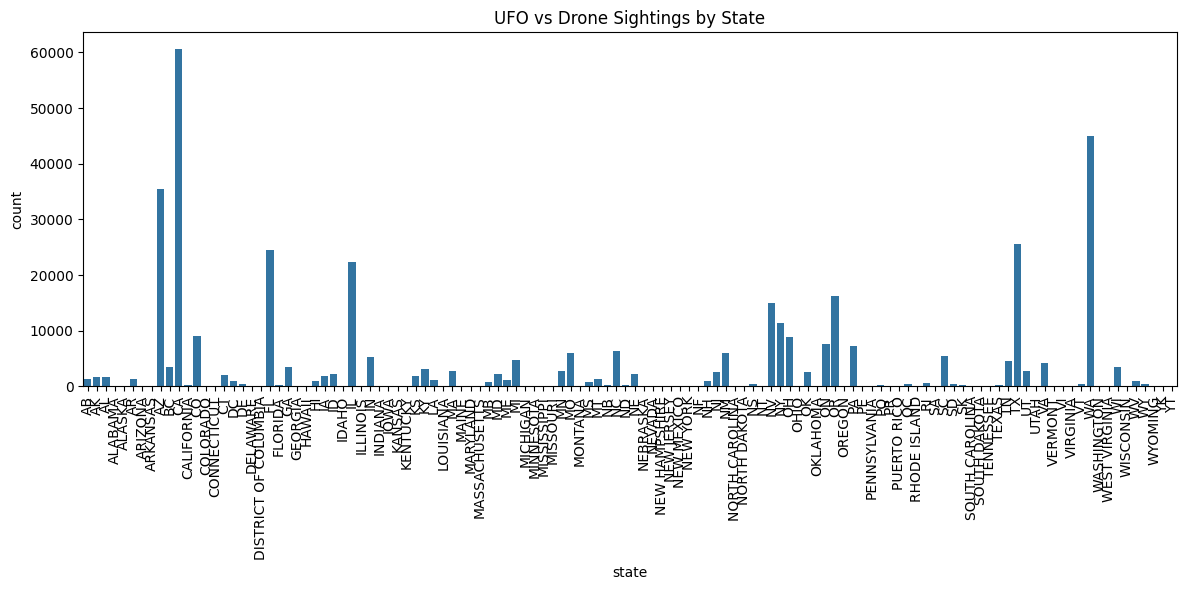

In [75]:
plt.figure(figsize=(12,6))
sns.countplot(data=final_df, x='state') 
plt.title('UFO vs Drone Sightings by State')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [77]:
sightings_by_month = final_df.groupby(['month', 'type']).size().reset_index(name='count')

plt.figure(figsize=(14,6))
sns.lineplot(data=sightings_by_month, x='month', y='count', marker='o')
plt.title('Sightings Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


KeyError: 'type'

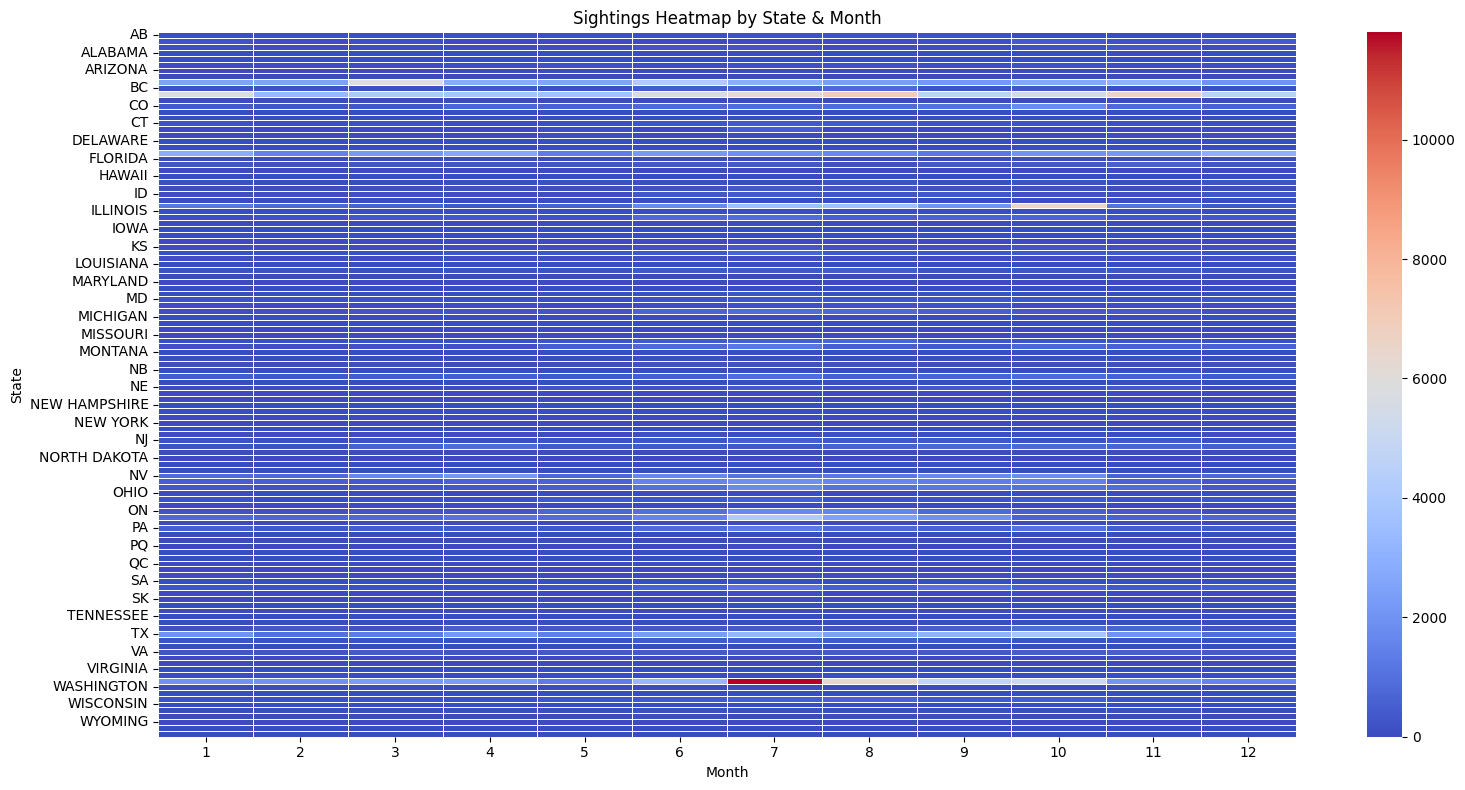

In [78]:
heat_df = final_df.groupby(['state', 'month']).size().unstack(fill_value=0)

plt.figure(figsize=(16,8))
sns.heatmap(heat_df, cmap='coolwarm', linecolor='white', linewidths=0.5)
plt.title('Sightings Heatmap by State & Month')
plt.xlabel('Month')
plt.ylabel('State')
plt.tight_layout()
plt.show()


Drone data was also used, but had too many missing values.

## Dataset Merging

All datasets were merged based on `state`, `city`, and `month`, where possible:
- UFO and drone sightings were merged on `city`, `state`, and `month`
- Population density were merged using `city` and `state`
- National Park proximity was calculated using state-level matching


### Monthly Sightings Comparison: UFOs vs Drones

This chart compares the number of UFO and drone sightings by month. By visualizing sightings over time, we can see whether they follow similar seasonal patterns.

This might help answer whether drone activity is mistaken for UFOs more often in certain months — such as summer, when people are outside more frequently.



In [80]:
monthly_counts = final_df.groupby(['month', 'type']).size().unstack().fillna(0)

monthly_counts.plot(kind='bar', figsize=(12,6))
plt.title('Sightings by Month: UFOs vs Drones')
plt.xlabel('Month')
plt.ylabel('Number of Sightings')
plt.xticks(rotation=0)
plt.legend(title='Type')
plt.tight_layout()
plt.show()


KeyError: 'type'

## Findings & Insights

Due to missing values from the dataset, drone sightings were filtered from the geographic map visual but are still used in monthly comparison charts.

Based on the merged and visualized data from UFO sightings, drone reports, and national park locations, several trends emerged:

-UFO sightings remain more frequent overall, but many peaks in drone sightings align with seasonal or regional patterns in UFO data.

-States with large rural areas like California, Texas, and Arizona showed the highest combined sighting counts.

-There are some patterns between drone/UFO hotspots and nearness to national parks. This may be due to dark skies or open airspace drawing attention to activity.

-Population density cannot explain the number of sightings as some sparsely populated states report high activity, possibly due to better visibility.

These insights suggest that some UFO sightings could potentially be explained by drone activity, especially in recent years. However, not all sightings correlate, leaving room for further analysis.
